### Feature Selection

Feature engineering is a rather creative work where we brainstorm combinations, ratios, aggregations, and flags, and we end up with far more features than we started with. But at some point we have to ask: which of these features are actually helping?

More features is not always better. Irrelevant features add noise that a model may overfit to. Redundant features double-count the same information and can destabilize linear models. And a model with 200 features is much harder to understand, debug, and maintain than one with 20.

Feature selection is the discipline of keeping only the features that earn their place. In this notebook we'll walk through a full toolkit from the simplest filters (remove anything that never changes) to the most thorough wrapper methods (try every possible subset). By the end you'll have a reliable process for trimming a bloated feature set down to its most predictive core.

**In this notebook we will cover:**
1. Removing constant and quasi-constant features
2. Removing duplicate and highly correlated features
3. Correlation with the target
4. Tree-based feature importance
5. L1 (Lasso) regularization for selection
6. Recursive Feature Elimination (RFE)
7. Mutual Information

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, mutual_info_classif,
    RFE, RFECV, SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [7]:
df = pd.read_csv("feature_engineering_data.csv")

In [9]:
df.head()

,info_0,info_1,info_2,info_3,info_4,corr_0,corr_1,corr_2,corr_3,corr_4,...,noise_6,noise_7,noise_8,noise_9,noise_10,noise_11,noise_12,noise_13,noise_14,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,0.369586,-0.274289,0.108996,1.424003,-0.014305,...,0.749938,-1.686877,-0.252353,0.583711,0.740421,0.669884,0.294831,-0.195725,0.537976,1
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,-0.616407,1.893758,0.913767,-0.689744,0.500101,...,0.772728,-0.077285,2.374466,-0.682935,-0.361087,-0.395067,-0.076188,-0.328725,-1.406811,1
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,0.016079,-0.245665,0.244597,-1.984585,-1.701935,...,-0.695810,-0.159329,1.784559,-0.165424,-1.327507,-0.501177,0.757056,0.689940,-0.200217,0
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-0.715817,-1.644256,0.926901,-0.861427,-1.292860,...,-1.866448,1.589896,-0.720154,0.241043,0.603917,1.512068,-0.153898,-0.539430,0.173068,0
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,1.448276,-0.446311,0.011751,-1.904567,0.138743,...,-0.320624,-0.607521,-0.715967,0.085046,-0.239455,-0.273132,1.349324,1.538016,-1.610022,1


I have constructed a dataset where we know the ground truth: exactly which features matter (info_0 through info_4) and which are noise. This dataset will help us understand whether our selection methods can recover these 5 informative features from 30 total is a direct test of their quality. And then you can apply these methods comfortably on different datasets.

### Why Feature Selection Matters

Imagine you're trying to predict house prices. You have 200 features. Fifty of them are genuinely meaningful like square footage, neighbourhood, age of the building. The other 150 are things like a random property ID, a city name that's the same for every row, or a duplicate of square footage measured in a different unit.

Adding those 150 useless features doesn't help instead it actively hurts the model performance. A model will learn unnecessary patterns in noise features that might fit well with the training data but don't generalise on unseen data. This is called overfitting, and it's one of the most common reasons ML models fail in production.

Feature selection methods fall into three broad families. **Filter methods** score each feature independently using statistics, without training a model. **Embedded methods** let feature selection happen inside the training process itself (Lasso, tree importance). **Wrapper methods** repeatedly train and evaluate the model with different feature subsets (RFE) and these are the most thorough but also the slowest. In practice, a good workflow uses all three in sequence.

### Removing Constant and Quasi-Constant Features

Think about a column in your dataset that has the same value for every single row, say a "country" field where every customer is from the same country. That column tells the model absolutely nothing. It cannot distinguish between a returning customer and a churned customer, because the value never changes.

A constant feature has zero variance. A quasi-constant feature has near-zero variance with maybe 99% of rows having value 0, with the occasional 1 scattered in. Such a feature provides almost no information and mostly adds noise.

`VarianceThreshold` from scikit-learn removes any feature whose variance falls below a threshold we set. A threshold of 0 catches exact constants; a threshold of 0.01 catches quasi-constants too. This is the cheapest feature selection step which requires no model, no target, and runs in milliseconds. Always do it first.

In [14]:
X = df.drop('target', axis=1)
y = df['target']

In [16]:
print(f'Starting features: {X.shape[1]}')

# Remove constant features with variance = 0
vt_zero = VarianceThreshold(threshold=0)
X_no_const = vt_zero.fit_transform(X)

removed_const = X.columns[~vt_zero.get_support()].tolist()

print(f'\nAfter removing constant (var=0): {X_no_const.shape[1]} features')
print(f'Removed: {removed_const}')

Starting features: 30

After removing constant (var=0): 28 features
Removed: ['const_0', 'const_1']


In [18]:
# Remove quasi-constant features (variance < 0.01)
vt_quasi = VarianceThreshold(threshold=0.01)
X_no_quasi = vt_quasi.fit_transform(X)

removed_quasi = X.columns[~vt_quasi.get_support()].tolist()

print(f'After removing quasi-constant (var<0.01): {X_no_quasi.shape[1]} features')
print(f'Removed: {removed_quasi}')

After removing quasi-constant (var<0.01): 27 features
Removed: ['const_0', 'const_1', 'const_2']


In [20]:
# Show variances of the removed features
print('\nVariances of removed features:')
print(X[removed_quasi].var().round(5))


Variances of removed features:
const_0    0.00000
const_1    0.00000
const_2    0.00991
dtype: float64


The `const_` features with almost no information were identified and removed as expected. Notice that this required no model training, no target variable, and ran almost instantly. This is the right first step in any feature selection pipeline: the free wins are always worth taking before spending compute on the more expensive methods.

### Removing Duplicate and Highly Correlated Features

Imagine you have both "salary in USD" and "salary in GBP" as columns. They carry identical information since one is just a multiple of the other. Keeping both doesn't give the model more signal; it just gives the same signal twice, which causes problems for linear models (multicollinearity makes coefficient estimates unstable and hard to interpret).

Exact duplicates are easy to spot and remove but apart from that high correlation (say, r > 0.9) is also an alternative to identify the same problem. When two features are nearly perfectly correlated, we should keep the one that has a stronger relationship with the target and drop the other.

The correlation heatmap below shows exactly what we'd expect: our `info_i` features and their derived `corr_i` copies (built by adding a small amount of noise to the original) are highly correlated with each other. Keeping both would be redundant.

In [24]:
# Check for exact duplicate features
n_duplicates = X.T.duplicated().sum()
print(f'Exact duplicate feature columns: {n_duplicates}')

if n_duplicates > 0:
    dup_features = X.columns[X.T.duplicated()].tolist()
    print(f'Duplicate features: {dup_features}')

Exact duplicate feature columns: 1
Duplicate features: ['const_1']


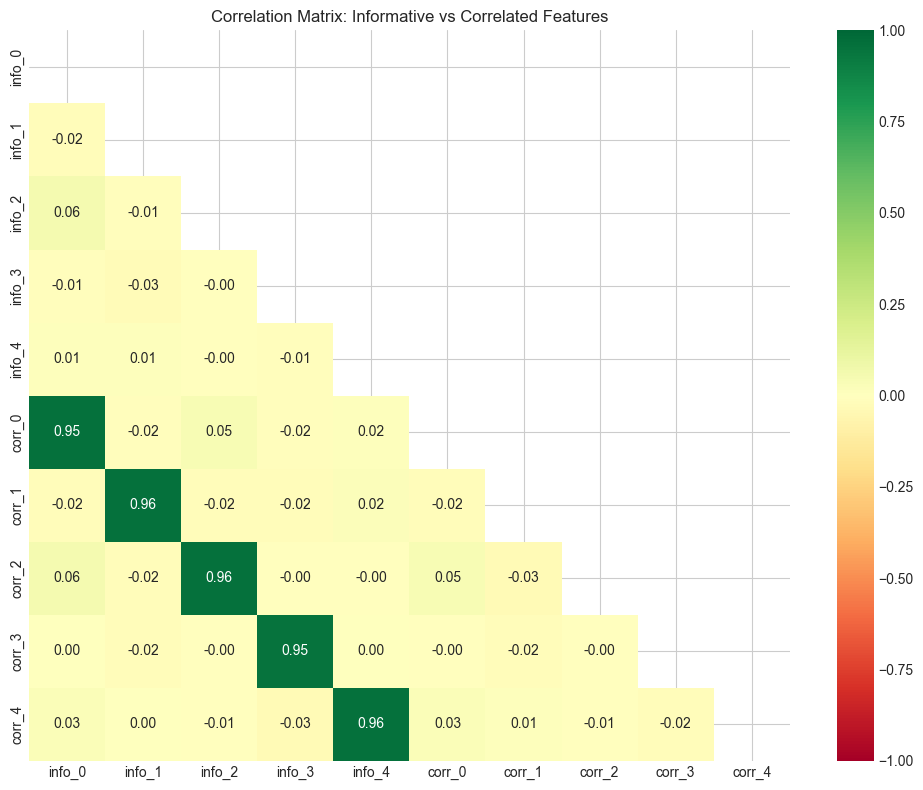

Notice: info_i and corr_i are highly correlated (corr_i is derived from info_i + noise)


In [26]:
# Correlation heatmap (subset for readability)
info_corr_cols = [c for c in X.columns if 'info' in c or 'corr' in c]
corr_matrix = X[info_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask, ax=ax,
            cmap='RdYlGn', center=0, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Informative vs Correlated Features')
plt.tight_layout()
plt.show()
print('Notice: info_i and corr_i are highly correlated (corr_i is derived from info_i + noise)')

In [28]:
def remove_correlated_features(X, y, threshold=0.9):
    """Among correlated pairs, drop the one less correlated with the target."""
    corr_matrix = X.corr().abs()
    target_corr = pd.Series(np.abs(np.corrcoef(X.T, y)[-1, :-1]), index=X.columns)

    to_drop = set()
    cols = corr_matrix.columns.tolist()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if corr_matrix.iloc[i, j] > threshold:
                # Drop the one less correlated with target
                drop_col = cols[i] if target_corr[cols[i]] < target_corr[cols[j]] else cols[j]
                to_drop.add(drop_col)

    return list(to_drop)

X_for_corr = X[[c for c in X.columns if 'const' not in c]]  # exclude constants first
to_drop = remove_correlated_features(X_for_corr, y, threshold=0.85)

print(f'Features removed due to high correlation (>0.85): {to_drop}')
print(f'Remaining: {len(X_for_corr.columns) - len(to_drop)} features')

Features removed due to high correlation (>0.85): ['corr_1', 'info_4', 'corr_0', 'info_3', 'corr_2']
Remaining: 20 features


### Correlation with the Target/Output Column

Before training any model, we can ask a direct question: how strongly is each feature linearly correlated with the thing we're trying to predict? A feature with near-zero correlation is very unlikely to help a linear model. It might help a non-linear model (which is why we'll also use Mutual Information later), but it's a reasonable first filter.

We plot the absolute Pearson correlation of each feature with the target, and draw a threshold line. Features below the threshold are candidates for removal. Notice in the chart how the truly informative features (`info_0` through `info_4`) stand clearly above the noise features even before fitting any model at all.

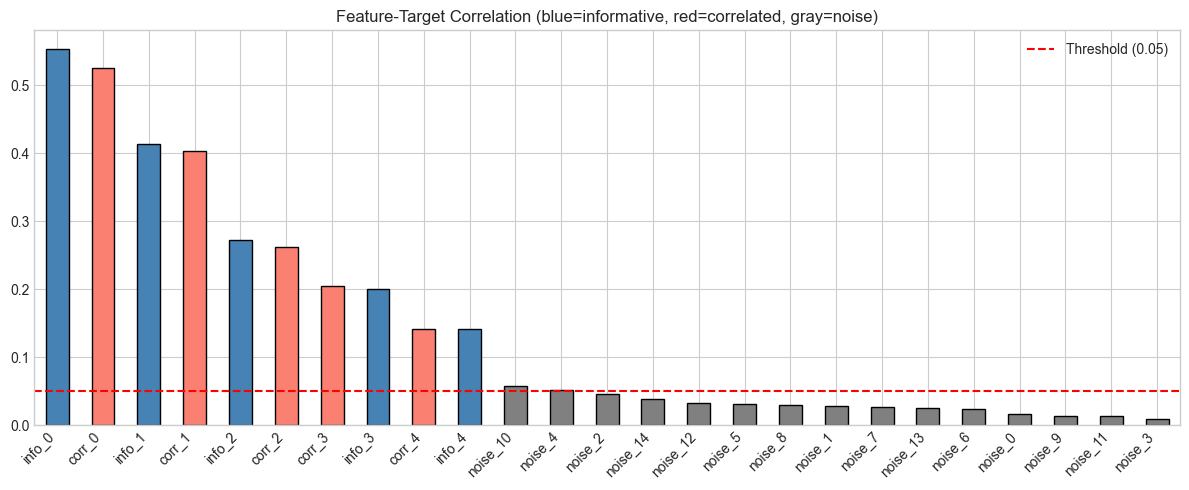


Features with |corr| < 0.05 (likely noise): ['noise_2', 'noise_14', 'noise_12', 'noise_5', 'noise_8', 'noise_1', 'noise_7', 'noise_13']...


In [31]:
# Pearson correlation with target (after removing constants)
X_valid = X[[c for c in X.columns if 'const' not in c]]

target_corr = X_valid.apply(lambda col: np.corrcoef(col, y)[0, 1]).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors = ['steelblue' if 'info' in c else ('salmon' if 'corr' in c else 'gray')
          for c in target_corr.index]
target_corr.plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(0.05, color='red', linestyle='--', label='Threshold (0.05)')
plt.title('Feature-Target Correlation (blue=informative, red=correlated, gray=noise)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

weak_features = target_corr[target_corr < 0.05].index.tolist()
print(f'\nFeatures with |corr| < 0.05 (likely noise): {weak_features[:8]}...')

### Tree-Based Feature Importance - Let the Model Tell You What It Learned

A Random Forest trains hundreds of decision trees. Each time a feature is used to make a split, we can measure how much that split reduced impurity in the training data. Summing these contributions across all trees gives us a feature importance score, a direct measure of how useful each feature was during training.

This is a powerful approach because it captures non-linear relationships. A feature that has zero linear correlation with the target might still be very important if it interacts with another feature in a complex way. Tree importance will surface it; Pearson correlation would have missed it.

The main limitation is a bias toward high-cardinality numeric features as they tend to get selected for splits more often just because they have more possible split points. For production use, SHAP values give a more reliable measure. But for quick feature screening, Random Forest importance is hard to beat.

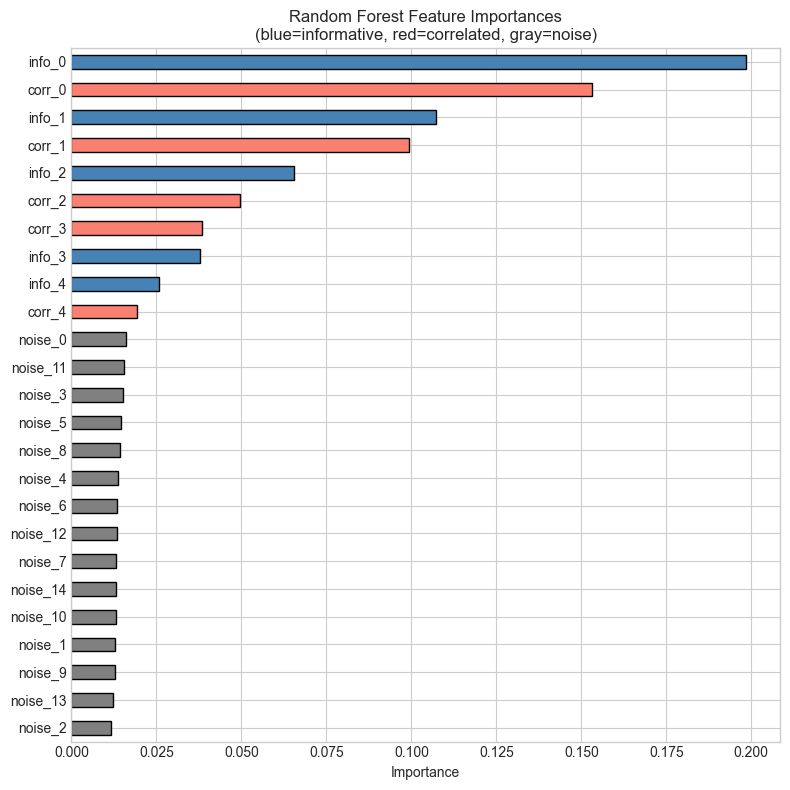

In [34]:
X_clean = X[[c for c in X.columns if 'const' not in c]]

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_clean, y)

importances = pd.Series(rf.feature_importances_, index=X_clean.columns).sort_values(ascending=True)

colors = ['steelblue' if 'info' in c else ('salmon' if 'corr' in c else 'gray')
          for c in importances.index]

plt.figure(figsize=(8, 8))
importances.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Random Forest Feature Importances\n(blue=informative, red=correlated, gray=noise)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [36]:
# Select top-k features
top10 = importances.sort_values(ascending=False).head(10).index.tolist()
print(f'Top 10 features by RF importance: {top10}')

# Compare accuracy: all features vs top 10
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_all  = cross_val_score(RandomForestClassifier(100, random_state=42), X_clean,        y, cv=cv).mean()
acc_top10 = cross_val_score(RandomForestClassifier(100, random_state=42), X_clean[top10], y, cv=cv).mean()

print(f'\nAccuracy with all {X_clean.shape[1]} features: {acc_all:.3f}')
print(f'Accuracy with top 10 features: {acc_top10:.3f}')

Top 10 features by RF importance: ['info_0', 'corr_0', 'info_1', 'corr_1', 'info_2', 'corr_2', 'corr_3', 'info_3', 'info_4', 'corr_4']

Accuracy with all 25 features: 0.918
Accuracy with top 10 features: 0.912


The bar chart tells a clear story: the informative features (blue) cluster at the top, and the noise features (gray) cluster at the bottom. The correlated features (red) also appear high in the ranking — they're not informative on their own, but they carry the same signal as the `info_` features. This is why we should remove correlated redundancies before running importance — otherwise we'll keep both the original and its near-duplicate, wasting capacity.

### L1 Regularization : Built-In Feature Selection for Linear Models

Lasso regression (and Logistic Regression with L1 penalty) works differently from the filter methods we've seen so far. Instead of evaluating features independently before training, it embeds the selection decision inside the training process itself.

In [40]:
from sklearn.preprocessing import StandardScaler

# Scale first (Lasso is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Logistic Regression with L1 penalty
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000)
lasso_model.fit(X_scaled, y)

coef = pd.Series(lasso_model.coef_[0], index=X_clean.columns)
zero_coef = coef[coef == 0].index.tolist()
nonzero_coef = coef[coef != 0].sort_values(key=abs, ascending=False)

print(f'Features zeroed out by Lasso (C=0.1): {len(zero_coef)}/{len(X_clean.columns)}')
print(f'Zeroed: {zero_coef}')
print(f'\nTop non-zero features:')
nonzero_coef.head(10).round(4)

Features zeroed out by Lasso (C=0.1): 17/25
Zeroed: ['corr_0', 'corr_1', 'corr_2', 'noise_0', 'noise_1', 'noise_3', 'noise_4', 'noise_5', 'noise_6', 'noise_7', 'noise_8', 'noise_9', 'noise_10', 'noise_11', 'noise_12', 'noise_13', 'noise_14']

Top non-zero features:


info_0     3.8896
info_1     2.8220
info_2    -1.8648
info_3     1.3529
info_4     0.7124
corr_4     0.1537
noise_2   -0.0063
corr_3     0.0005
dtype: float64

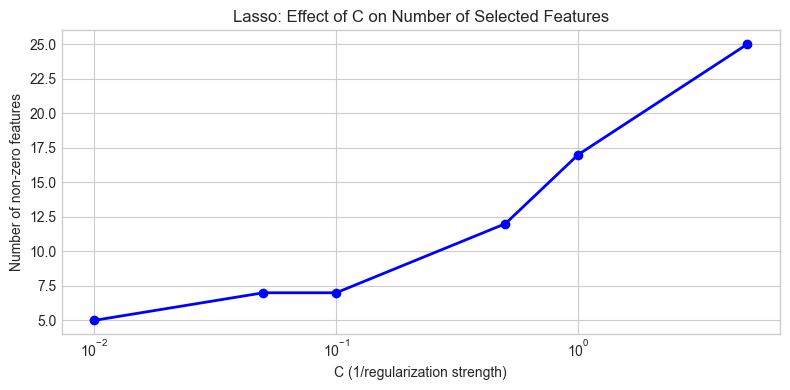

In [42]:
# Show effect of different C values
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
nonzero_counts = []
for C in C_values:
    m = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
    m.fit(X_scaled, y)
    nonzero_counts.append((m.coef_[0] != 0).sum())

plt.figure(figsize=(8, 4))
plt.plot(C_values, nonzero_counts, 'bo-', lw=2)
plt.xscale('log')
plt.xlabel('C (1/regularization strength)')
plt.ylabel('Number of non-zero features')
plt.title('Lasso: Effect of C on Number of Selected Features')
plt.tight_layout()
plt.show()

### Recursive Feature Elimination

RFE takes a straightforward approach: train the model, find the least important feature, remove it, and repeat. It's like pruning a tree one branch at a time, always cutting the weakest branch. By the time you've done this enough times, only the genuinely useful features remain.

The basic `RFE` requires us to specify how many features we want to keep. But `RFECV` removes that decision by using cross-validation at each step where it tries removing features one by one and measures the validation score, so it automatically finds the number of features that maximises predictive performance.

RFECV is the most thorough method in our toolkit because it actually checks whether each removal hurts the model. Its downside is that it can be slow on large datasets with many features.

In [47]:
# RFE with LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=10, step=1)
rfe.fit(X_scaled, y)

selected_rfe = X_clean.columns[rfe.support_].tolist()
print(f'RFE selected features (top 10):')
print(selected_rfe)

RFE selected features (top 10):
['info_0', 'info_1', 'info_2', 'info_3', 'info_4', 'corr_0', 'corr_1', 'corr_2', 'corr_3', 'corr_4']


In [49]:
# Ranking of all features
ranking = pd.Series(rfe.ranking_, index=X_clean.columns).sort_values()

print('Feature ranking (1 = selected):')
print(ranking.head(12))

Feature ranking (1 = selected):
info_0      1
info_1      1
info_2      1
info_3      1
info_4      1
corr_0      1
corr_1      1
corr_2      1
corr_3      1
corr_4      1
noise_2     2
noise_10    3
dtype: int64


Optimal number of features: 5
Selected: ['info_0', 'info_1', 'info_2', 'info_3', 'info_4']


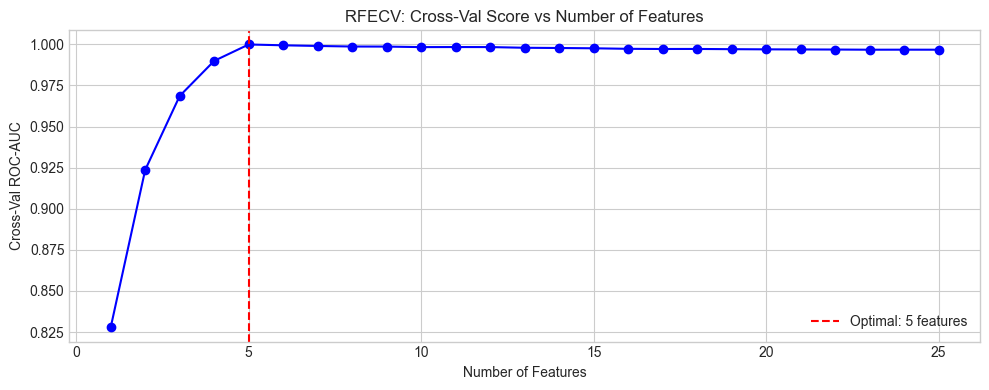

In [51]:
# RFECV: automatically find the optimal number of features
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(estimator=LogisticRegression(max_iter=1000), cv=cv_strat, scoring='roc_auc', step=1)
rfecv.fit(X_scaled, y)

print(f'Optimal number of features: {rfecv.n_features_}')
selected_rfecv = X_clean.columns[rfecv.support_].tolist()
print(f'Selected: {selected_rfecv}')

# Plot cross-validation scores vs number of features
plt.figure(figsize=(10, 4))
mean_scores = rfecv.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores)+1), mean_scores, 'bo-')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Val ROC-AUC')
plt.title('RFECV: Cross-Val Score vs Number of Features')
plt.legend()
plt.tight_layout()
plt.show()

The cross-validation score curve rises as we add features, peaks, and then flattens or drops. The red dashed line shows where RFECV placed the optimal cutoff. This is the honest answer and not a number we guessed upfront, but the number that actually maximises held-out performance. In a real project, this curve is something we'd look at carefully: a sharp peak suggests the selection is tight; a wide plateau suggests the model is robust to small changes in the feature set.

### Mutual Information : Detecting Non-Linear Relationships

Pearson correlation measures linear association. If the relationship between a feature and the target is non-linear say, a U-shaped relationship then correlation will underestimate its value and might even report zero.

Mutual Information (MI) measures something more general: how much does knowing this feature reduce uncertainty about the target? It makes no assumption about the shape of the relationship. A feature with MI = 0 is statistically independent of the target. A feature with high MI is strongly associated with it, in whatever shape that relationship takes.

`mutual_info_classif` from scikit-learn computes this score for classification tasks. `SelectKBest` then uses it to pick the top k features. Notice in the bar chart how MI successfully ranks the informative features at the top even for features that might have complex, non-linear relationships with the target.

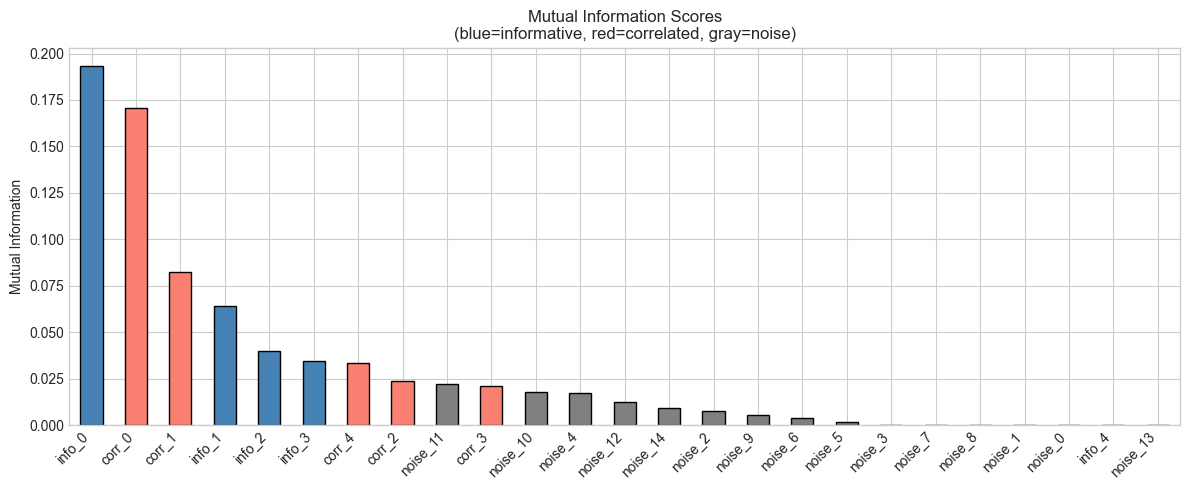


SelectKBest (MI, k=10) selected: ['info_0', 'info_1', 'info_2', 'info_3', 'corr_0', 'corr_1', 'corr_2', 'corr_3', 'corr_4', 'noise_11']


In [54]:
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_clean.columns).sort_values(ascending=False)

colors = ['steelblue' if 'info' in c else ('salmon' if 'corr' in c else 'gray')
          for c in mi_series.index]

plt.figure(figsize=(12, 5))
mi_series.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Mutual Information Scores\n(blue=informative, red=correlated, gray=noise)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mutual Information')
plt.tight_layout()
plt.show()

# SelectKBest with MI
selector = SelectKBest(mutual_info_classif, k=10)
X_mi_selected = selector.fit_transform(X_scaled, y)
selected_mi = X_clean.columns[selector.get_support()].tolist()
print(f'\nSelectKBest (MI, k=10) selected: {selected_mi}')

Like the tree importance chart, MI successfully separates the informative features from the noise but it does so without training a model at all. It's measuring statistical dependency directly from the data distribution. For features with non-linear relationships with the target, MI would outperform Pearson correlation significantly. For linear relationships, they give similar rankings.

In [57]:
# Summary: compare which methods successfully identify the truly informative features
print('=== Feature Selection Methods Comparison ===')
print(f'True informative features: {[f for f in X_clean.columns if "info" in f]}')
print()
print(f'RF Importance (top 10):   {[f for f in top10 if "info" in f or "corr" in f]}')
print(f'RFE (10 features):        {[f for f in selected_rfe if "info" in f or "corr" in f]}')
print(f'RFECV (auto):             {[f for f in selected_rfecv if "info" in f or "corr" in f]}')
print(f'Mutual Info (top 10):     {[f for f in selected_mi if "info" in f or "corr" in f]}')
print(f'Lasso (C=0.1):            {[f for f in nonzero_coef.index if "info" in f or "corr" in f]}')

=== Feature Selection Methods Comparison ===
True informative features: ['info_0', 'info_1', 'info_2', 'info_3', 'info_4']

RF Importance (top 10):   ['info_0', 'corr_0', 'info_1', 'corr_1', 'info_2', 'corr_2', 'corr_3', 'info_3', 'info_4', 'corr_4']
RFE (10 features):        ['info_0', 'info_1', 'info_2', 'info_3', 'info_4', 'corr_0', 'corr_1', 'corr_2', 'corr_3', 'corr_4']
RFECV (auto):             ['info_0', 'info_1', 'info_2', 'info_3', 'info_4']
Mutual Info (top 10):     ['info_0', 'info_1', 'info_2', 'info_3', 'corr_0', 'corr_1', 'corr_2', 'corr_3', 'corr_4']
Lasso (C=0.1):            ['info_0', 'info_1', 'info_2', 'info_3', 'info_4', 'corr_4', 'corr_3']


All four methods broadly agree mostly since they each recover most of the truly informative features and avoid the pure noise. The differences are in the details: some methods include a correlated feature instead of the original, some miss one informative feature when it has a weaker marginal effect. In a real project, when multiple methods agree that a feature is important, you can be confident keeping it. When they disagree, that's a signal to investigate the feature more carefully before deciding.